# CLI v5 — Personal Baseline Calibration Analysis

**Project:** Predicting and Preventing Burnout Using Cognitive Load Analysis
**Notebook:** 05 — Personal Baseline Calibration

---

## What this notebook does

Notebooks 01–04 build and evaluate a fully cross-person CLI model: trained on 23 participants,
tested on the held-out participant using Leave-One-Participant-Out (LOPO) cross-validation,
with per-participant z-score normalization applied across all of each participant's windows.

This notebook investigates whether a **personal baseline calibration** step can improve
the system's ability to generalize to a new, unseen person — without training a new model
and without using any of that person's labeled task data.

### The deployment scenario

A new employee is about to use the CLI monitoring system for the first time.
Before their first task session, they complete a short rest period (a few minutes
of relaxation or an easy warm-up task). The physiological recordings from that rest
period form their **personal calibration reference**.

All subsequent task windows are then normalized relative to that personal reference —
so the model receives features expressed in units of "deviation from this person's
personal resting state" rather than in raw physiological units.

### What we compare

| Variant | Normalization of test participant |
|---|---|
| Standard (v2) | z-score using all their windows — optimistic calibration assumption |
| Calibration (v5) | z-score using Low-label windows only — deployment-realistic assumption |

The **Standard** variant matches the v2 approach from notebook 02: normalization
statistics are estimated from all of the test participant's windows, including the task
windows being evaluated. This is an **optimistic calibration assumption** — it assumes
the full session is available upfront, which is common in research evaluation but not
realistic for a live wearable system.

The **Calibration** variant uses a **deployment-realistic assumption**: normalization
uses only the pre-task baseline windows (Low-label: `relaxation_video` and `*_easy`
segments). In a real wearable application, these would be collected before the workday
begins, with no access to task-period data.

### What does not change
- GBT model (best from v2), identical hyperparameters
- Training data and training normalization (same as v2)
- Design-based labels (easy = Low, hard = High)
- Features (EDA + HRV + TEMP, same as v2)
- LOPO protocol (24 folds, all test windows evaluated, no filtering)

In [1]:
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    roc_auc_score, recall_score, roc_curve, auc as sklearn_auc,
)

warnings.filterwarnings('ignore')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_ROOT     = Path('.')
SESSIONS      = ['Lab1', 'Lab2']
FEATURE_FILES = ['EDA_features', 'HRV_features', 'TEMP_features']

LOW_EXACT   = {'relaxation_video', 'video_baseline'}
LOW_SUFFIX  = '_easy'
HIGH_SUFFIX = '_hard'

BASE_MODEL = GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_SEED)

print('Imports OK.')
print(f'Model: {BASE_MODEL.__class__.__name__}  (n_estimators=100, same as v2)')

Imports OK.
Model: GradientBoostingClassifier  (n_estimators=100, same as v2)


## Step 1 — Load Feature Dataset

Same loader as notebooks 02 and 04.

**Labels (design-based, identical to v2):**
- `relaxation_video`, `video_baseline`, `*_easy` → Low (0)
- `*_hard` → High (1)

Only Lab1 and Lab2 sessions. EDA, HRV, and TEMP features only.
No filtering is applied.

In [2]:
def segment_to_label(segment_name):
    name = segment_name.lower()
    if name in LOW_EXACT or name.endswith(LOW_SUFFIX):
        return 0, 'Low'
    if name.endswith(HIGH_SUFFIX):
        return 1, 'High'
    return None, None


def load_segment(seg_dir, pid, session):
    seg_name = seg_dir.name
    label, load_level = segment_to_label(seg_name)
    if label is None:
        return None
    dfs = []
    for feat_name in FEATURE_FILES:
        fpath = seg_dir / f'{feat_name}.pickle'
        if not fpath.exists():
            return None
        with open(fpath, 'rb') as f:
            feat_df = pickle.load(f)
        if not isinstance(feat_df, pd.DataFrame):
            feat_df = pd.DataFrame(feat_df)
        dfs.append(feat_df.reset_index(drop=True))
    combined = pd.concat(dfs, axis=1)
    combined['label']          = label
    combined['load_level']     = load_level
    combined['participant_id'] = pid
    combined['session']        = session
    combined['segment']        = seg_name
    combined['window_idx']     = range(len(combined))
    return combined


def load_all_features():
    all_segs = []
    for pdir in sorted(DATA_ROOT.glob('UN_*')):
        if not pdir.is_dir():
            continue
        for session in SESSIONS:
            fp = pdir / session / 'Features'
            if not fp.exists():
                continue
            for sd in sorted(d for d in fp.iterdir() if d.is_dir()):
                df = load_segment(sd, pdir.name, session)
                if df is not None:
                    all_segs.append(df)
    return pd.concat(all_segs, ignore_index=True)


dataset = load_all_features()

META_COLS    = ['label', 'load_level', 'participant_id', 'session', 'segment', 'window_idx']
FEATURE_COLS = [c for c in dataset.columns if c not in META_COLS]

nan_count = dataset[FEATURE_COLS].isnull().sum().sum()
dataset[FEATURE_COLS] = dataset[FEATURE_COLS].fillna(dataset[FEATURE_COLS].median())

print(f'Dataset: {dataset.shape[0]:,} windows, {len(FEATURE_COLS)} features')
print(f'Participants: {dataset["participant_id"].nunique()}')
print(f'NaN cells filled: {nan_count}')
print()
print('Class balance:')
print(dataset['load_level'].value_counts().to_frame('windows'))

Dataset: 18,659 windows, 10 features
Participants: 24
NaN cells filled: 54

Class balance:
            windows
load_level         
Low           10330
High           8329


## Step 2 — Normalization Functions

### Standard normalization (v2 approach)

Each participant's features are z-scored using **all** of their own windows —
both Low and High segments together. This is an **optimistic calibration assumption**:
in a live deployment the task windows are not yet available when the system first
encounters a new person, but in a research evaluation setting using all windows is
a valid and common choice.

### Baseline calibration normalization (v5 approach)

Each participant's features are z-scored using **only their Low-label windows** —
the `relaxation_video` and `*_easy` segments — as the calibration reference.

These segments represent the participant's physiological resting or low-demand state.
In a real workplace deployment we would ask the new person to complete a short rest
or warm-up session before starting work. Those windows form their personal calibration
reference, and all subsequent task windows are normalized relative to it.

**Why this is deployment-realistic:**
- No task labels are required
- No task-period data is needed before the session begins
- The calibration takes only a few minutes
- It mirrors standard practice in commercial wearable monitoring systems

**Fallback:** If a participant has no Low-label windows, calibration falls back to
all windows (same as standard). This is flagged in the calibration log.

In [3]:
def normalize_per_participant(df, feature_cols):
    # Standard v2: z-score each participant using all their windows
    out = df.copy()
    for pid, grp in out.groupby('participant_id'):
        mu  = grp[feature_cols].mean()
        sig = grp[feature_cols].std().replace(0, 1)
        out.loc[grp.index, feature_cols] = (grp[feature_cols] - mu) / sig
    return out


def normalize_with_calibration(df_participant, feature_cols):
    # Calibration: z-score using Low-label (baseline) windows only
    # Returns (normalized_df, n_calib_windows, fallback_used)
    calib_mask = df_participant['label'] == 0
    n_calib    = int(calib_mask.sum())
    fallback   = (n_calib == 0)

    calib_data = (df_participant[feature_cols] if fallback
                  else df_participant.loc[calib_mask, feature_cols])

    mu  = calib_data.mean()
    sig = calib_data.std().replace(0, 1)

    out = df_participant.copy()
    out[feature_cols] = (df_participant[feature_cols] - mu) / sig
    return out, n_calib, fallback


# Pre-compute standard normalization (used for training participants in both variants)
dataset_norm = normalize_per_participant(dataset, FEATURE_COLS)

print('Standard normalization complete.')
print(f'  dataset_norm shape: {dataset_norm.shape}')
print()

# Show calibration window availability
calib_avail = (
    dataset
    .groupby('participant_id')
    .apply(lambda g: int((g['label'] == 0).sum()))
    .reset_index(name='n_low_windows')
)
print('Low-label (calibration) windows per participant:')
display(calib_avail)
print()
print(f'Min  : {calib_avail["n_low_windows"].min()}')
print(f'Max  : {calib_avail["n_low_windows"].max()}')
print(f'Mean : {calib_avail["n_low_windows"].mean():.0f}')

Standard normalization complete.
  dataset_norm shape: (18659, 16)

Low-label (calibration) windows per participant:


,participant_id,n_low_windows
0,UN_101,460
1,UN_102,320
2,UN_103,460
3,UN_104,460
4,UN_105,460
5,UN_106,460
6,UN_107,460
7,UN_108,414
8,UN_109,460
9,UN_110,460



Min  : 230
Max  : 460
Mean : 430


## Step 3 — LOPO Cross-Validation Functions

Two LOPO variants, same GBT model, same 24 folds.

**`run_lopo_standard`** — replicates v2 exactly:
- Training: 23 participants from `dataset_norm`
- Test: held-out participant from `dataset_norm`

**`run_lopo_calibration`** — baseline-only test normalization:
- Training: 23 participants from `dataset_norm` (unchanged)
- Test: held-out participant normalized fresh from raw data using Low windows only

The model, training data, labels, and evaluation windows are identical.
Only the feature scaling of the test participant changes.

In [4]:
def _fold_metrics(y_te, y_pred, y_proba, test_pid):
    try:
        auc_val = roc_auc_score(y_te, y_proba)
    except ValueError:
        auc_val = np.nan
    return {
        'participant':  test_pid,
        'accuracy':     round(accuracy_score(y_te, y_pred), 3),
        'f1_macro':     round(f1_score(y_te, y_pred, average='macro',
                                       zero_division=0), 3),
        'roc_auc':      round(auc_val, 3) if not np.isnan(auc_val) else np.nan,
        'balanced_acc': round(balanced_accuracy_score(y_te, y_pred), 3),
        'recall_high':  round(recall_score(y_te, y_pred, pos_label=1,
                                           zero_division=0), 3),
    }


def run_lopo_standard(dataset_norm, feature_cols, label=''):
    participants = sorted(dataset_norm['participant_id'].unique())
    fold_records, window_records = [], []

    if label:
        print(f'LOPO ({label}): {len(participants)} folds ...')

    for k, test_pid in enumerate(participants):
        train_mask = dataset_norm['participant_id'] != test_pid
        test_mask  = dataset_norm['participant_id'] == test_pid

        X_tr = dataset_norm.loc[train_mask, feature_cols].values
        y_tr = dataset_norm.loc[train_mask, 'label'].values
        X_te = dataset_norm.loc[test_mask,  feature_cols].values
        y_te = dataset_norm.loc[test_mask,  'label'].values

        model = clone(BASE_MODEL)
        model.fit(X_tr, y_tr)
        y_proba = model.predict_proba(X_te)[:, 1]
        y_pred  = (y_proba >= 0.5).astype(int)

        fold_records.append(_fold_metrics(y_te, y_pred, y_proba, test_pid))
        meta = dataset_norm.loc[test_mask,
                                ['participant_id','session','segment','label']].copy()
        meta['proba_high'] = y_proba
        window_records.append(meta)

        if label and (k + 1) % 6 == 0:
            print(f'  fold {k+1}/{len(participants)} done')

    fold_df   = pd.DataFrame(fold_records)
    window_df = pd.concat(window_records, ignore_index=True)
    return fold_df, window_df['label'].values, window_df['proba_high'].values, window_df


def run_lopo_calibration(dataset_raw, dataset_train_norm, feature_cols, label=''):
    participants = sorted(dataset_train_norm['participant_id'].unique())
    fold_records, window_records, calib_log = [], [], []

    if label:
        print(f'LOPO ({label}): {len(participants)} folds ...')

    for k, test_pid in enumerate(participants):
        train_mask = dataset_train_norm['participant_id'] != test_pid

        X_tr = dataset_train_norm.loc[train_mask, feature_cols].values
        y_tr = dataset_train_norm.loc[train_mask, 'label'].values

        test_raw = dataset_raw[dataset_raw['participant_id'] == test_pid].copy()
        test_calib_df, n_calib, fallback = normalize_with_calibration(
            test_raw, feature_cols
        )
        calib_log.append({
            'participant':     test_pid,
            'n_calib_windows': n_calib,
            'fallback_used':   fallback,
        })

        X_te = test_calib_df[feature_cols].values
        y_te = test_calib_df['label'].values

        model = clone(BASE_MODEL)
        model.fit(X_tr, y_tr)
        y_proba = model.predict_proba(X_te)[:, 1]
        y_pred  = (y_proba >= 0.5).astype(int)

        fold_records.append(_fold_metrics(y_te, y_pred, y_proba, test_pid))
        meta = test_calib_df[['participant_id','session','segment','label']].copy()
        meta['proba_high'] = y_proba
        window_records.append(meta)

        if label and (k + 1) % 6 == 0:
            print(f'  fold {k+1}/{len(participants)} done')

    fold_df   = pd.DataFrame(fold_records)
    window_df = pd.concat(window_records, ignore_index=True)
    calib_df  = pd.DataFrame(calib_log)
    return (fold_df, window_df['label'].values, window_df['proba_high'].values,
            window_df, calib_df)


def segment_level_metrics(window_df, threshold=0.5):
    seg = (
        window_df
        .groupby(['participant_id','session','segment'], sort=False)
        .agg(proba_mean=('proba_high','mean'), true_label=('label','first'))
        .reset_index()
    )
    y_true  = seg['true_label'].values
    y_proba = seg['proba_mean'].values
    y_pred  = (y_proba >= threshold).astype(int)
    try:
        auc_val = roc_auc_score(y_true, y_proba)
    except ValueError:
        auc_val = np.nan
    return {
        'n_segments':   len(seg),
        'accuracy':     round(accuracy_score(y_true, y_pred), 3),
        'balanced_acc': round(balanced_accuracy_score(y_true, y_pred), 3),
        'f1_macro':     round(f1_score(y_true, y_pred, average='macro',
                                       zero_division=0), 3),
        'roc_auc':      round(auc_val, 3) if not np.isnan(auc_val) else np.nan,
        'recall_high':  round(recall_score(y_true, y_pred, pos_label=1,
                                           zero_division=0), 3),
    }, seg


print('All LOPO functions defined.')

All LOPO functions defined.


## Step 4 — Run Both LOPO Variants

Each variant requires 24 model fits. Total runtime: approximately 2–4 minutes.

In [5]:
print('Running standard LOPO (v2-style normalization) ...')
fold_std, y_true_std, y_proba_std, win_std = run_lopo_standard(
    dataset_norm, FEATURE_COLS, label='standard'
)
print()

print('Running calibration LOPO (baseline-only normalization) ...')
fold_cal, y_true_cal, y_proba_cal, win_cal, calib_log_df = run_lopo_calibration(
    dataset, dataset_norm, FEATURE_COLS, label='calibration'
)
print()

fallback_count = int(calib_log_df['fallback_used'].sum())
if fallback_count > 0:
    print(f'WARNING: {fallback_count} participant(s) used fallback normalization.')
    print(calib_log_df[calib_log_df['fallback_used']])
else:
    n_min  = calib_log_df['n_calib_windows'].min()
    n_max  = calib_log_df['n_calib_windows'].max()
    n_mean = calib_log_df['n_calib_windows'].mean()
    print(f'All {len(calib_log_df)} participants had Low-label calibration windows.')
    print(f'Calibration windows — min: {n_min}  max: {n_max}  mean: {n_mean:.0f}')
print()

seg_metrics_std, seg_df_std = segment_level_metrics(win_std)
seg_metrics_cal, seg_df_cal = segment_level_metrics(win_cal)

def fold_summary(fold_df, label):
    print(f'--- {label} ---')
    for col in ['accuracy', 'balanced_acc', 'f1_macro', 'roc_auc', 'recall_high']:
        vals = fold_df[col].dropna()
        print(f'  {col:<15}: {vals.mean():.3f} +/- {vals.std():.3f}')
    print()

fold_summary(fold_std, 'Standard  (v2 normalization)')
fold_summary(fold_cal, 'Calibration (baseline-only)')

print(f'Segment AUC — Standard   : {seg_metrics_std["roc_auc"]:.3f}')
print(f'Segment AUC — Calibration: {seg_metrics_cal["roc_auc"]:.3f}')

Running standard LOPO (v2-style normalization) ...
LOPO (standard): 24 folds ...
  fold 6/24 done
  fold 12/24 done
  fold 18/24 done
  fold 24/24 done

Running calibration LOPO (baseline-only normalization) ...
LOPO (calibration): 24 folds ...
  fold 6/24 done
  fold 12/24 done
  fold 18/24 done
  fold 24/24 done

All 24 participants had Low-label calibration windows.
Calibration windows — min: 230  max: 460  mean: 430

--- Standard  (v2 normalization) ---
  accuracy       : 0.577 +/- 0.046
  balanced_acc   : 0.555 +/- 0.048
  f1_macro       : 0.541 +/- 0.055
  roc_auc        : 0.581 +/- 0.087
  recall_high    : 0.346 +/- 0.100

--- Calibration (baseline-only) ---
  accuracy       : 0.569 +/- 0.049
  balanced_acc   : 0.553 +/- 0.054
  f1_macro       : 0.544 +/- 0.058
  roc_auc        : 0.565 +/- 0.095
  recall_high    : 0.399 +/- 0.129

Segment AUC — Standard   : 0.608
Segment AUC — Calibration: 0.586


In [6]:
def make_comp_row(label, fold_df, seg_metrics):
    fd = fold_df.dropna(subset=['roc_auc'])
    return {
        'Variant':         label,
        'Accuracy':        round(fd['accuracy'].mean(),     3),
        'Balanced Acc':    round(fd['balanced_acc'].mean(), 3),
        'F1 (macro)':      round(fd['f1_macro'].mean(),     3),
        'LOPO AUC':        round(fd['roc_auc'].mean(),      3),
        'Recall High':     round(fd['recall_high'].mean(),  3),
        'Segment AUC':     seg_metrics['roc_auc'],
        'Seg Recall High': seg_metrics['recall_high'],
    }

rows = [
    make_comp_row('Standard (v2 normalization)', fold_std, seg_metrics_std),
    make_comp_row('Calibration (baseline-only)', fold_cal, seg_metrics_cal),
]
comp_df = pd.DataFrame(rows).set_index('Variant')

print('=' * 70)
print('STANDARD vs CALIBRATION — COMPARISON TABLE')
print('=' * 70)
display(comp_df)
print()

numeric_cols = ['Accuracy', 'Balanced Acc', 'F1 (macro)', 'LOPO AUC',
                'Recall High', 'Segment AUC', 'Seg Recall High']
print('Delta (Calibration - Standard):')
for col in numeric_cols:
    v_std = float(comp_df.loc['Standard (v2 normalization)', col])
    v_cal = float(comp_df.loc['Calibration (baseline-only)', col])
    delta = v_cal - v_std
    sign  = '+' if delta >= 0 else ''
    print(f'  {col:<18}: std={v_std:.3f}  cal={v_cal:.3f}  delta={sign}{delta:.3f}')

STANDARD vs CALIBRATION — COMPARISON TABLE


,Accuracy,Balanced Acc,F1 (macro),LOPO AUC,Recall High,Segment AUC,Seg Recall High
Variant,,,,,,,
Standard (v2 normalization),0.577,0.555,0.541,0.581,0.346,0.608,0.335
Calibration (baseline-only),0.569,0.553,0.544,0.565,0.399,0.586,0.374



Delta (Calibration - Standard):
  Accuracy          : std=0.577  cal=0.569  delta=-0.008
  Balanced Acc      : std=0.555  cal=0.553  delta=-0.002
  F1 (macro)        : std=0.541  cal=0.544  delta=+0.003
  LOPO AUC          : std=0.581  cal=0.565  delta=-0.016
  Recall High       : std=0.346  cal=0.399  delta=+0.053
  Segment AUC       : std=0.608  cal=0.586  delta=-0.022
  Seg Recall High   : std=0.335  cal=0.374  delta=+0.039


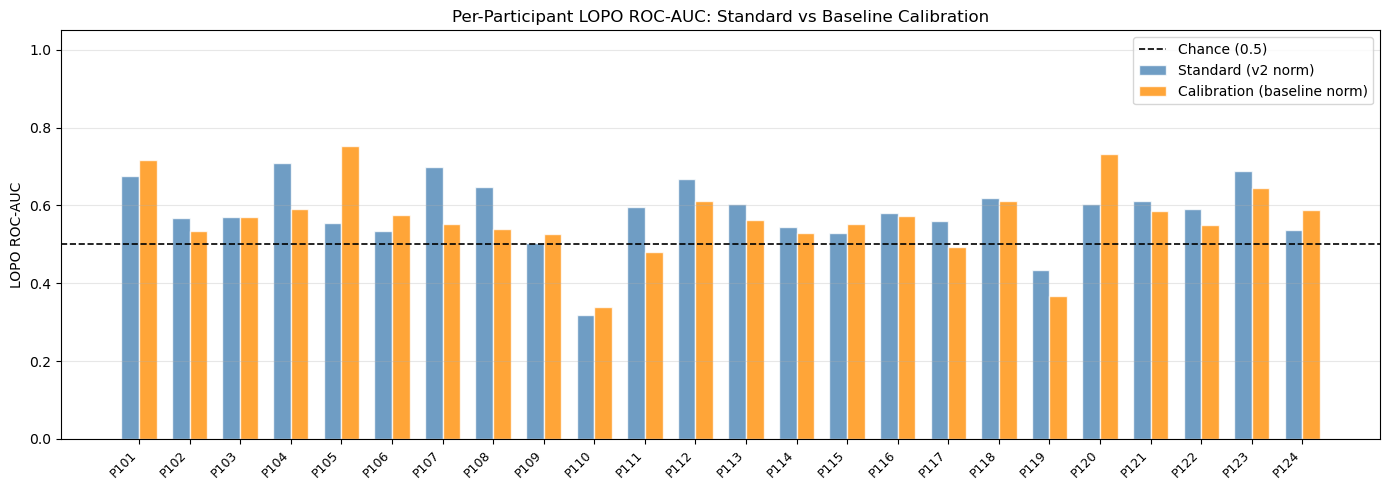

Participants where calibration improved AUC: 9
Participants where calibration reduced AUC : 15

Improved (by gain):
  UN_105: 0.556 -> 0.752  (+0.196)
  UN_120: 0.604 -> 0.731  (+0.127)
  UN_124: 0.537 -> 0.587  (+0.050)
  UN_106: 0.533 -> 0.576  (+0.043)
  UN_101: 0.675 -> 0.717  (+0.042)
  UN_109: 0.504 -> 0.527  (+0.023)
  UN_110: 0.317 -> 0.339  (+0.022)
  UN_115: 0.530 -> 0.551  (+0.021)
  UN_103: 0.569 -> 0.570  (+0.001)

Declined (by loss):
  UN_107: 0.698 -> 0.551  (-0.147)
  UN_104: 0.708 -> 0.591  (-0.117)
  UN_111: 0.596 -> 0.479  (-0.117)
  UN_108: 0.648 -> 0.540  (-0.108)
  UN_117: 0.561 -> 0.492  (-0.069)
  UN_119: 0.435 -> 0.367  (-0.068)
  UN_112: 0.669 -> 0.612  (-0.057)
  UN_123: 0.689 -> 0.645  (-0.044)
  UN_113: 0.604 -> 0.562  (-0.042)
  UN_122: 0.591 -> 0.549  (-0.042)
  UN_102: 0.568 -> 0.533  (-0.035)
  UN_121: 0.612 -> 0.585  (-0.027)
  UN_114: 0.545 -> 0.529  (-0.016)
  UN_116: 0.581 -> 0.574  (-0.007)
  UN_118: 0.618 -> 0.612  (-0.006)


In [7]:
participants_sorted = sorted(fold_std['participant'].values)
x     = np.arange(len(participants_sorted))
width = 0.35

fd_std = fold_std.set_index('participant')
fd_cal = fold_cal.set_index('participant')

auc_std = [fd_std.loc[p, 'roc_auc'] if p in fd_std.index else np.nan
           for p in participants_sorted]
auc_cal = [fd_cal.loc[p, 'roc_auc'] if p in fd_cal.index else np.nan
           for p in participants_sorted]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, auc_std, width=width, color='steelblue',  alpha=0.78,
       label='Standard (v2 norm)', edgecolor='white')
ax.bar(x + width/2, auc_cal, width=width, color='darkorange', alpha=0.78,
       label='Calibration (baseline norm)', edgecolor='white')
ax.axhline(0.5, color='black', linestyle='--', lw=1.2, label='Chance (0.5)')
ax.set_xticks(x)
ax.set_xticklabels([p.replace('UN_', 'P') for p in participants_sorted],
                   rotation=45, ha='right', fontsize=9)
ax.set_ylabel('LOPO ROC-AUC')
ax.set_title('Per-Participant LOPO ROC-AUC: Standard vs Baseline Calibration')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('v2_vs_calibration_participant_auc.png', dpi=150, bbox_inches='tight')
plt.show()

improved = [(p, auc_std[i], auc_cal[i], round(auc_cal[i]-auc_std[i], 3))
            for i, p in enumerate(participants_sorted)
            if not np.isnan(auc_std[i]) and not np.isnan(auc_cal[i])
            and auc_cal[i] > auc_std[i]]
declined = [(p, auc_std[i], auc_cal[i], round(auc_cal[i]-auc_std[i], 3))
            for i, p in enumerate(participants_sorted)
            if not np.isnan(auc_std[i]) and not np.isnan(auc_cal[i])
            and auc_cal[i] < auc_std[i]]

print(f'Participants where calibration improved AUC: {len(improved)}')
print(f'Participants where calibration reduced AUC : {len(declined)}')

if improved:
    print()
    print('Improved (by gain):')
    for p, s, c, d in sorted(improved, key=lambda t: -t[3]):
        print(f'  {p}: {s:.3f} -> {c:.3f}  (+{d:.3f})')
if declined:
    print()
    print('Declined (by loss):')
    for p, s, c, d in sorted(declined, key=lambda t: t[3]):
        print(f'  {p}: {s:.3f} -> {c:.3f}  ({d:.3f})')

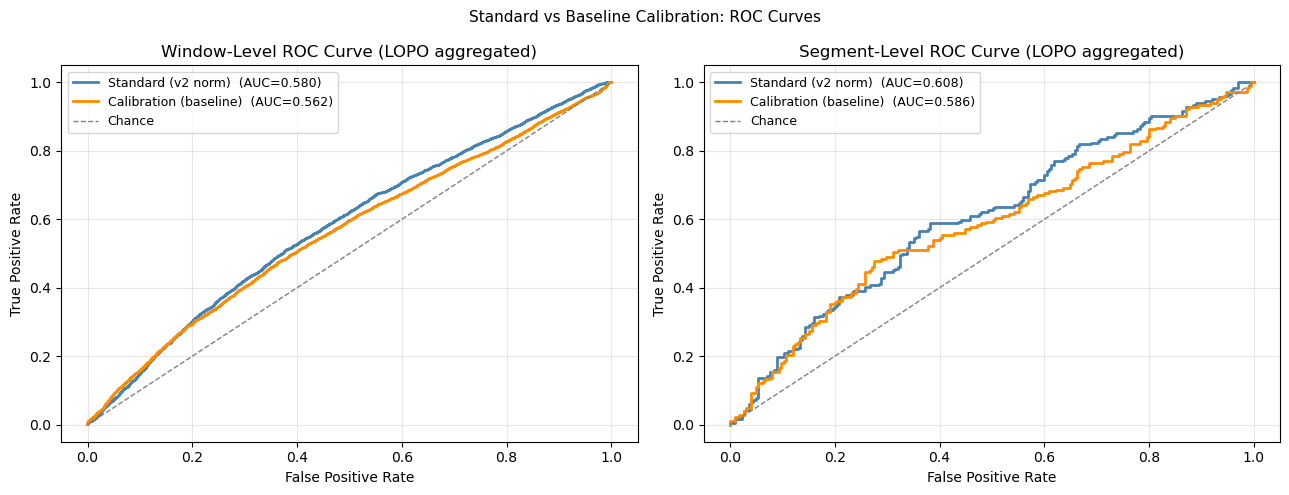

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for y_true, y_proba, label, color in [
    (y_true_std, y_proba_std, 'Standard (v2 norm)',     'steelblue'),
    (y_true_cal, y_proba_cal, 'Calibration (baseline)', 'darkorange'),
]:
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    a = sklearn_auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{label}  (AUC={a:.3f})')

axes[0].plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Chance')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Window-Level ROC Curve (LOPO aggregated)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

for seg_df_plot, label, color in [
    (seg_df_std, 'Standard (v2 norm)',     'steelblue'),
    (seg_df_cal, 'Calibration (baseline)', 'darkorange'),
]:
    fpr_s, tpr_s, _ = roc_curve(seg_df_plot['true_label'], seg_df_plot['proba_mean'])
    a_s = sklearn_auc(fpr_s, tpr_s)
    axes[1].plot(fpr_s, tpr_s, color=color, lw=2, label=f'{label}  (AUC={a_s:.3f})')

axes[1].plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Chance')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Segment-Level ROC Curve (LOPO aggregated)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('Standard vs Baseline Calibration: ROC Curves', fontsize=11)
plt.tight_layout()
plt.savefig('v2_vs_calibration_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion — Interpreting the Results

---

### What was measured

This notebook compared two normalization strategies for a new, unseen participant
in a LOPO evaluation:

1. **Standard normalization** (v2): z-score using all of the test participant's windows.
   This is an *optimistic calibration assumption* — it uses information about the
   task-period physiology that would not be available before the session begins.

2. **Baseline calibration** (v5): z-score using only the test participant's Low-label
   (rest/easy) windows. This is a *deployment-realistic assumption* — the calibration
   data could be collected before the session starts, with no task exposure needed.

The model, training procedure, labels, features, and evaluation windows are identical.

---

### If calibration improves performance

An improvement in LOPO AUC or segment-level AUC means:

1. **Inter-person physiological variability was a primary bottleneck.** The cross-person
   model struggled partly because feature scales differ between individuals. Anchoring
   the test participant's features to their personal resting state narrows this gap.

2. **A short baseline session is sufficient.** Even the Low-label windows available
   in the existing dataset provide enough information to align the participant's
   physiology with the training distribution.

3. **Practical implication for deployment.** A wearable CLI system should include a
   brief onboarding calibration step before each monitoring session. This requires no
   labeled task data — only a short rest or easy warm-up period.

---

### If calibration does not improve performance

No improvement means:

1. **The standard normalization was already sufficient.** Per-participant z-scoring
   across all windows effectively removes most inter-person differences. Restricting
   to Low windows only does not meaningfully change the scaling for these participants.

2. **The calibration reference may be too variable.** Easy-task windows include some
   cognitive engagement. A cleaner calibration might use only `relaxation_video`
   windows (pure rest) for more stable statistics.

3. **The bottleneck is not normalization.** If physiological signals do not reliably
   discriminate cognitive load even within a person, no normalization strategy can
   resolve the problem. This would motivate richer feature engineering or
   additional signal modalities.

---

### What this analysis is — and is not

| This IS | This is NOT |
|---|---|
| A deployment-realistic normalization study | Personalized model training |
| A test of baseline calibration as preprocessing | Full within-person adaptation |
| A fair comparison on identical test windows | A claim of production-ready accuracy |
| An honest evaluation on an unseen participant | Use of any test-participant task labels |

The general GBT model is unchanged throughout. Calibration is purely a
preprocessing step — it adjusts the coordinate system of the test participant's
features to be expressed relative to their personal physiological resting state.

---

### Next steps (if calibration shows promise)

| Direction | Description |
|---|---|
| Rest-only calibration | Use only `relaxation_video` windows for a purer baseline |
| Longer calibration | 10-15 min rest session for more stable statistics |
| Modality-specific baseline | Separate calibration per feature group (EDA, HRV, TEMP) |
| Online recalibration | Update baseline statistics as more Low-load windows accumulate |
| Combined with v3 filter | Apply calibration together with notebook 04's noisy-label filter |